In [1]:
import os 
import pandas as pd
import glob

In [20]:
# log_paths = glob.glob('../logs/exp1d/ft1d/*/*.csv')
log_paths = glob.glob('../logs/exp2d/*/*/*.csv')
# log_paths = glob.glob('../logs/exp1d/lno1d/*/*.csv')
# log_paths = glob.glob('../logs/exp1d/fno1d/*/*.csv')

In [21]:
log_df = pd.DataFrame(columns=('model', 'dataset', 'coarse_level', 'resolution', 'residual', 'seed', 'test_l2'))
for i, log_path in enumerate(log_paths):
    dataset, log_info = log_path.split('/')[-2:]
    model_nm, _, _, trares, testres, clevel, mlevel, seed = log_info.split('.')[0].split('-')
    clevel = int(clevel[2:])
    trares = int(trares)
    testres = int(testres)
    seed = int(seed[4:])
    log = pd.read_csv(log_path)

    if mlevel[2:] == 'x':
        mlevel = 'null'
    elif mlevel[2:] == '0':
        mlevel = 'diag'

    # mlevel = int(mlevel[2:]) if mlevel[2:] != 'x' else -1
    best_l2 = log.test_l2.min()
    log_df.loc[i] = [model_nm, dataset, clevel, trares, mlevel, seed, best_l2]

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns 

#### test relative L2 error on different residual type

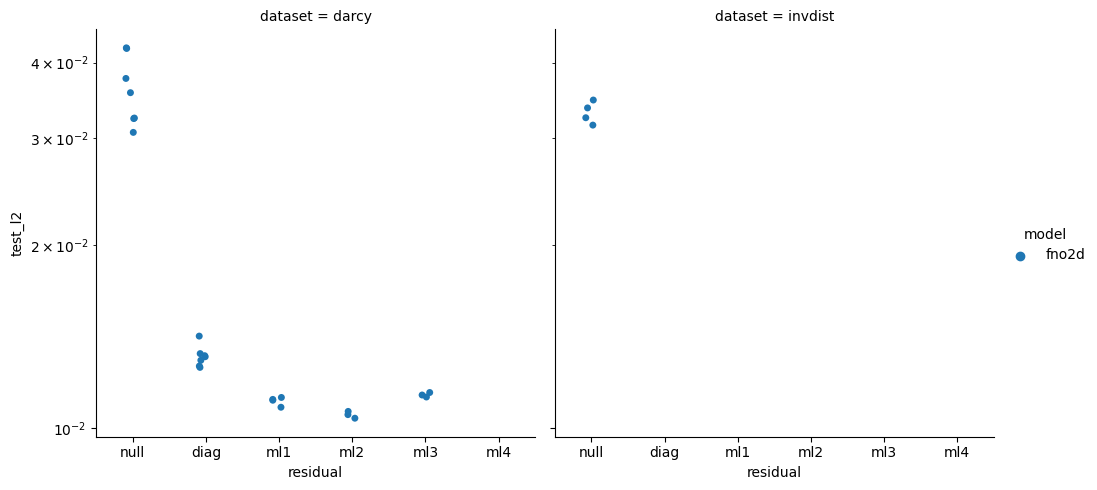

In [23]:
sub_df = log_df[(log_df.resolution == 141) & (log_df.coarse_level == 0)]# & (log_df.dataset != 'burgers')]
g = sns.catplot(data=sub_df, x='residual', y='test_l2', col='dataset', kind='strip', order=['null','diag','ml1', 'ml2', 'ml3', 'ml4'], hue='model')
g.set(yscale='log')


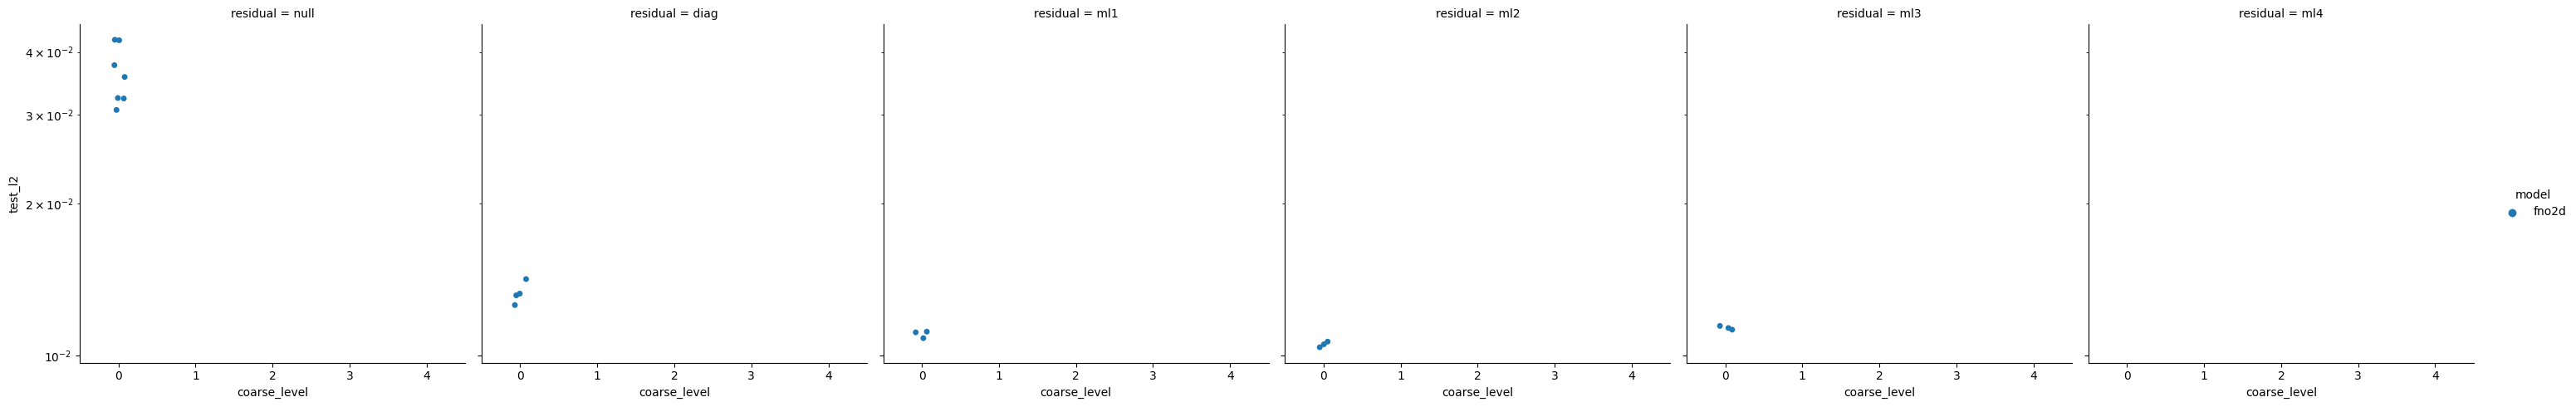

In [16]:
sub_df = log_df[(log_df.resolution == 141) & (log_df.dataset == 'darcy') & (log_df.model == 'fno2d')]
g = sns.catplot(data=sub_df, x='coarse_level', y='test_l2', col='residual', kind='strip', order=[0, 1, 2, 3, 4], col_order=['null', 'diag', 'ml1', 'ml2', 'ml3', 'ml4'], hue='model')
g.set(yscale='log')

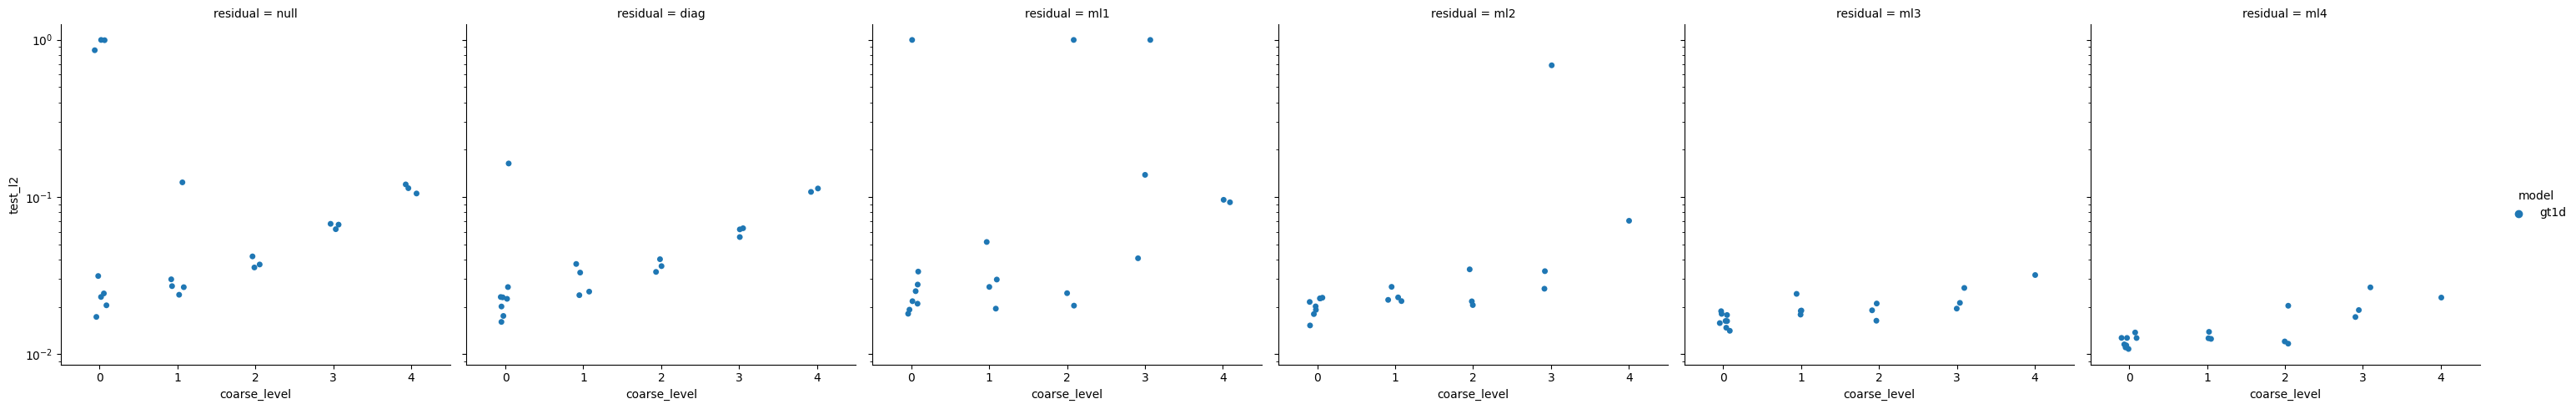

In [7]:
sub_df = log_df[(log_df.resolution == 512) & (log_df.dataset == 'poisson') & (log_df.model == 'gt1d')]
g = sns.catplot(data=sub_df, x='coarse_level', y='test_l2', col='residual', kind='strip', order=[0, 1, 2, 3, 4], col_order=['null', 'diag', 'ml1', 'ml2', 'ml3', 'ml4'], hue='model')
g.set(yscale='log')